In [1]:
import pandas as pd
#Load the Excel File
df = pd.read_excel("Telco_customer_churn.xlsx")
# View the first few  rows 
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [2]:
# information about table
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

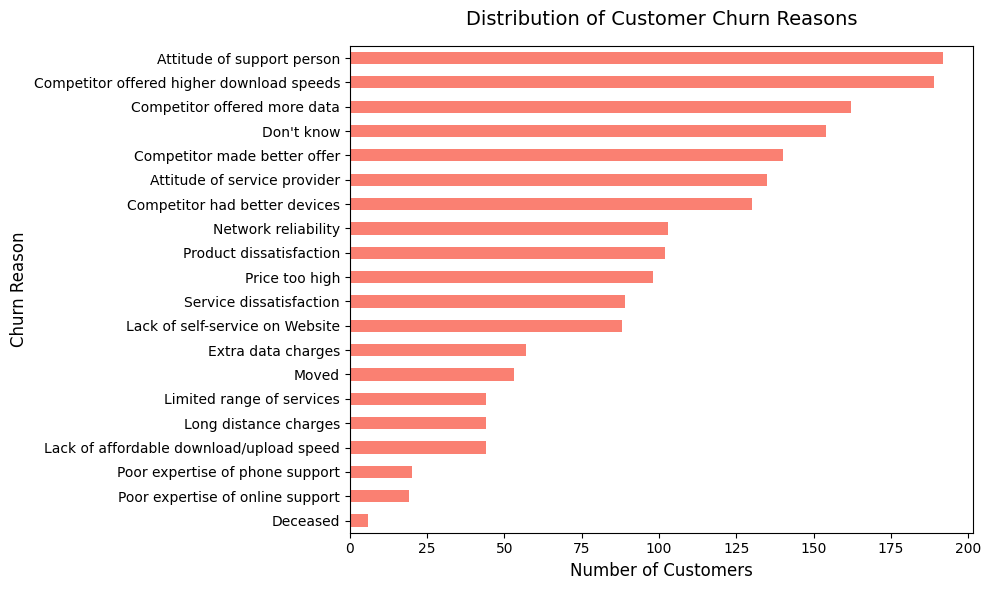

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
churn_reasons = df['Churn Reason'].value_counts().sort_values(ascending=True)
plt.figure(figsize=(10, 6))
churn_reasons.plot(kind='barh', color='salmon')

plt.title('Distribution of Customer Churn Reasons', fontsize=14, pad=15)
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Churn Reason', fontsize=12)
plt.tight_layout()  

plt.show()

The objective is not to change customer demographics such as city, state, senior-citizen status, partner status, or dependents. Instead, these attributes are used to identify similar customer groups. Clustering is applied to segment customers based on demographic and service usage characteristics, allowing the business to understand customer behavior and design targeted retention strategies for each segment.

<ol>
  <li>
    <strong>Primary Focus (Actionable Service & Contract Attributes)</strong>
    <p>These represent the product plans, service choices, and terms you can directly adjust, upgrade, or modify to prevent a user from churning.</p>
    <ul>
      <li>Contract</li>
      <li>Phone Service</li>
      <li>Multiple Lines</li>
      <li>Internet Service</li>
      <li>Online Security</li>
      <li>Online Backup</li>
      <li>Device Protection</li>
      <li>Tech Support</li>
      <li>Streaming TV</li>
      <li>Streaming Movies</li>
    </ul>
  </li>
  
  <li>
    <strong>Secondary Focus (Demographic Customer Traits)</strong>
    <p>Fixed personal traits you cannot change, but are critical for building the target "persona" profile of each cluster.</p>
    <ul>
      <li>Senior Citizen</li>
      <li>Partner</li>
      <li>Dependents</li>
    </ul>
  </li>
  
  <li>
    <strong>Tertiary Focus (Geographic Categorization)</strong>
    <p>Location-based tags useful for identifying localized trends or regional marketing campaigns.</p>
    <ul>
      <li>Country</li>
      <li>State</li>
      <li>City</li>
    </ul>
  </li>
</ol>

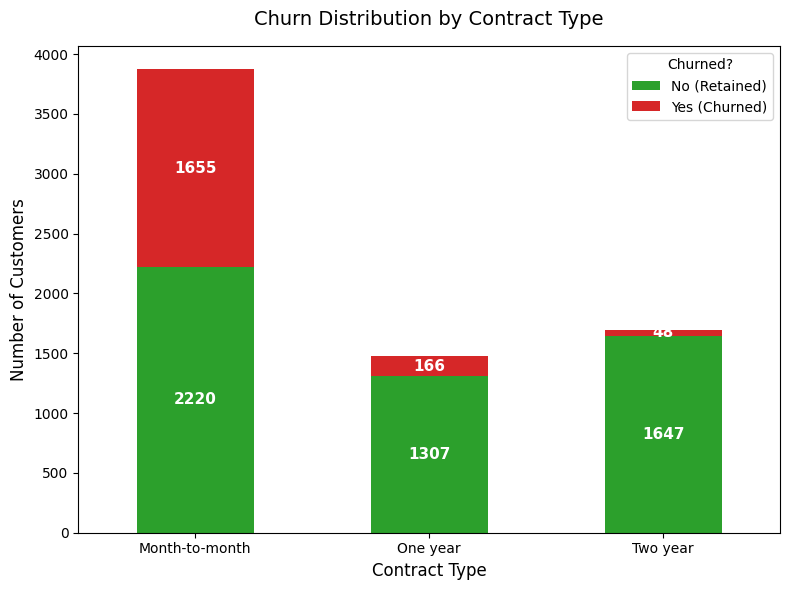

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a cross-tabulation of Contract and Churn Label
contract_churn = pd.crosstab(df['Contract'], df['Churn Label'])

# Reorder the contracts logically from shortest to longest commitment
contract_order = ['Month-to-month', 'One year', 'Two year']
contract_churn = contract_churn.reindex(contract_order)

# Plotting the stacked bar chart (using clean colors: Green for Retained, Red for Churned)
ax = contract_churn.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#2ca02c', '#d62728'])

# Customizing titles and labels
plt.title('Churn Distribution by Contract Type', fontsize=14, pad=15)
plt.xlabel('Contract Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)  # Keeps contract names completely horizontal and readable
plt.legend(title='Churned?', labels=['No (Retained)', 'Yes (Churned)'])

# Add exact value labels inside the stacked segments for clarity
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:  # Only label non-empty segments
        ax.text(x + width/2, 
                y + height/2, 
                f'{int(height)}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                weight='bold',
                fontsize=11)

plt.tight_layout()
plt.show()

In [5]:
# Map the contract types to ordered numbers
df['Contract_encoded'] = df['Contract'].map({
    'Two year': 0,
    'One year': 1,
    'Month-to-month': 2
})

# Verify the new encoded column against the original data
df[['Contract', 'Contract_encoded']].drop_duplicates()

,Contract,Contract_encoded
0,Month-to-month,2
24,Two year,0
41,One year,1


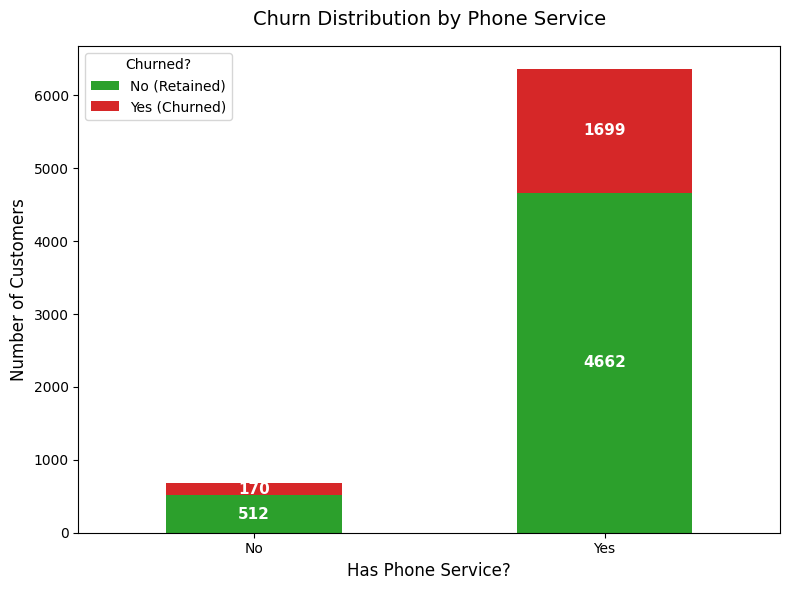

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a cross-tabulation of Phone Service and Churn Label
phone_churn = pd.crosstab(df['Phone Service'], df['Churn Label'])

# Plotting the stacked bar chart
ax = phone_churn.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#2ca02c', '#d62728'])

# Customizing titles and labels
plt.title('Churn Distribution by Phone Service', fontsize=14, pad=15)
plt.xlabel('Has Phone Service?', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Churned?', labels=['No (Retained)', 'Yes (Churned)'])

# Add exact value labels inside the stacked segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, 
                y + height/2, 
                f'{int(height)}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                weight='bold',
                fontsize=11)

plt.tight_layout()
plt.show()

In [7]:
# Map Phone Service based on your preference
df['Phone Service_encoded'] = df['Phone Service'].map({
    'No': 0,
    'Yes': 1
})

# Verify the mapping works exactly as expected
df[['Phone Service', 'Phone Service_encoded']].drop_duplicates()


,Phone Service,Phone Service_encoded
0,Yes,1
6,No,0


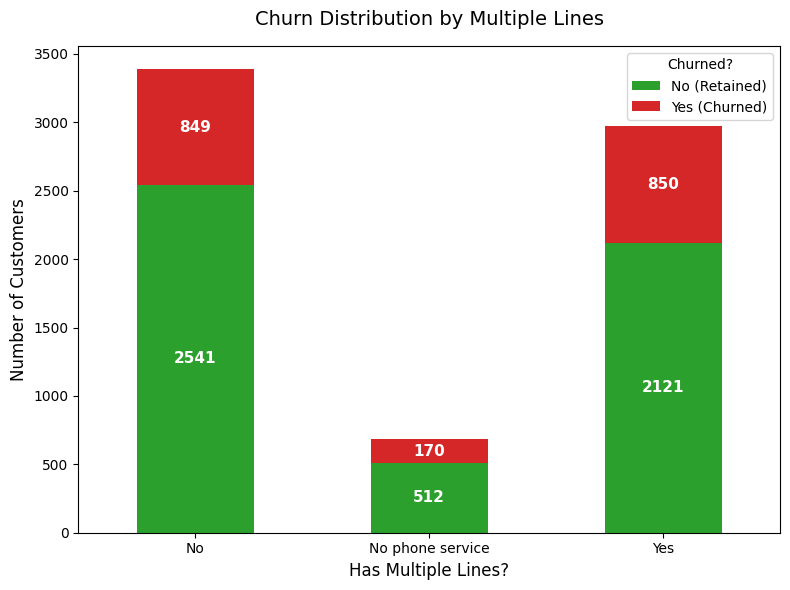

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a cross-tabulation of Multiple Lines and Churn Label
multiple_lines_churn = pd.crosstab(df['Multiple Lines'], df['Churn Label'])

# Plotting the stacked bar chart
ax = multiple_lines_churn.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#2ca02c', '#d62728'])

# Customizing titles and labels
plt.title('Churn Distribution by Multiple Lines', fontsize=14, pad=15)
plt.xlabel('Has Multiple Lines?', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Churned?', labels=['No (Retained)', 'Yes (Churned)'])

# Add exact value labels inside the stacked segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, 
                y + height/2, 
                f'{int(height)}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                weight='bold',
                fontsize=11)

plt.tight_layout()
plt.show()

In [9]:
# Map Multiple Lines based on your preference
df['Multiple Lines_encoded'] = df['Multiple Lines'].map({
    'No phone service': 0,
    'Yes': 1,
    'No': 2
})

# Verify the mapping works exactly as expected
df[['Multiple Lines', 'Multiple Lines_encoded']].drop_duplicates()


,Multiple Lines,Multiple Lines_encoded
0,No,2
2,Yes,1
6,No phone service,0


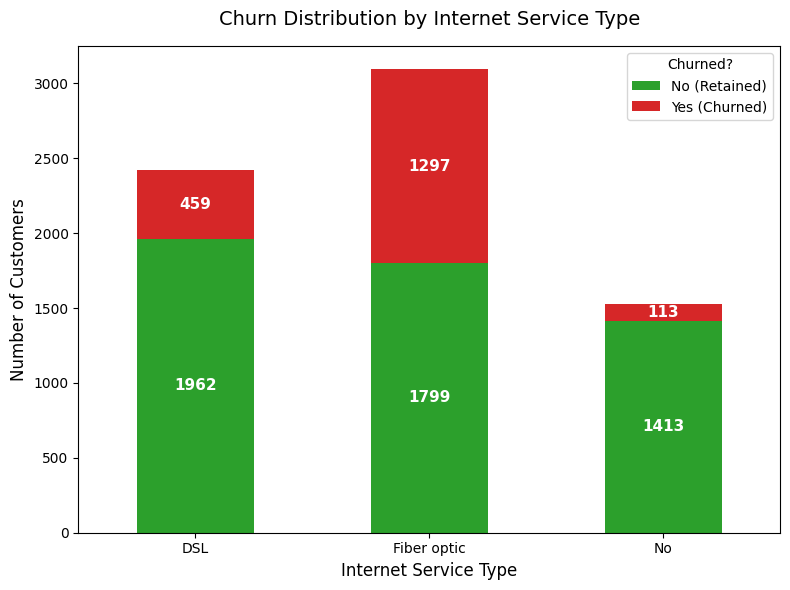

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a cross-tabulation of Internet Service and Churn Label
internet_churn = pd.crosstab(df['Internet Service'], df['Churn Label'])

# Plotting the stacked bar chart
ax = internet_churn.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#2ca02c', '#d62728'])

# Customizing titles and labels
plt.title('Churn Distribution by Internet Service Type', fontsize=14, pad=15)
plt.xlabel('Internet Service Type', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Churned?', labels=['No (Retained)', 'Yes (Churned)'])

# Add exact value labels inside the stacked segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, 
                y + height/2, 
                f'{int(height)}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                weight='bold',
                fontsize=11)

plt.tight_layout()
plt.show()

In [11]:
# Map Internet Service based on your preference
df['Internet Service_encoded'] = df['Internet Service'].map({
    'No': 0,
    'DSL': 1,
    'Fiber optic': 2
})

# Verify the mapping works exactly as expected
df[['Internet Service', 'Internet Service_encoded']].drop_duplicates()

,Internet Service,Internet Service_encoded
0,DSL,1
1,Fiber optic,2
7,No,0


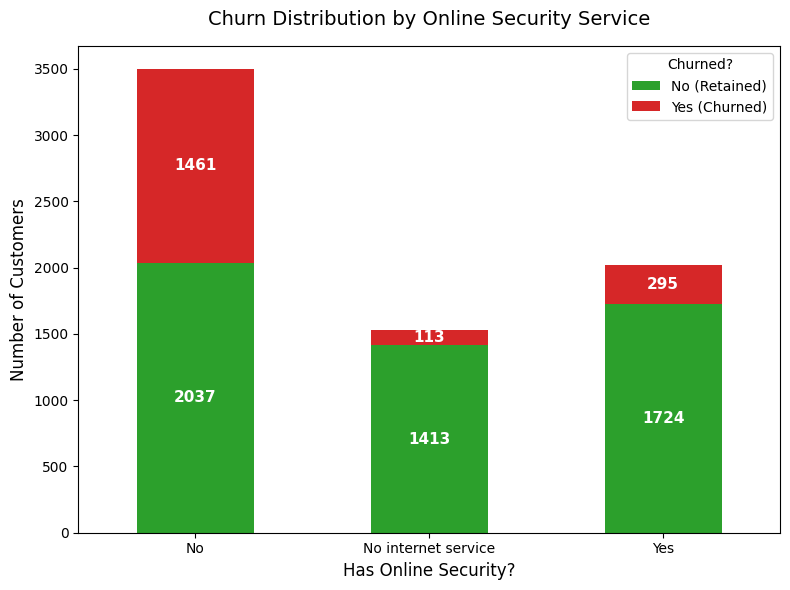

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a cross-tabulation of Online Security and Churn Label
security_churn = pd.crosstab(df['Online Security'], df['Churn Label'])

# Plotting the stacked bar chart
ax = security_churn.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#2ca02c', '#d62728'])

# Customizing titles and labels
plt.title('Churn Distribution by Online Security Service', fontsize=14, pad=15)
plt.xlabel('Has Online Security?', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Churned?', labels=['No (Retained)', 'Yes (Churned)'])

# Add exact value labels inside the stacked segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, 
                y + height/2, 
                f'{int(height)}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                weight='bold',
                fontsize=11)

plt.tight_layout()
plt.show()

In [13]:
# Map Online Security based on your preference
df['Online Security_encoded'] = df['Online Security'].map({
    'No internet service': 0,
    'Yes': 1,
    'No': 2
})

# Verify the mapping works exactly as expected
df[['Online Security', 'Online Security_encoded']].drop_duplicates()

,Online Security,Online Security_encoded
0,Yes,1
1,No,2
7,No internet service,0


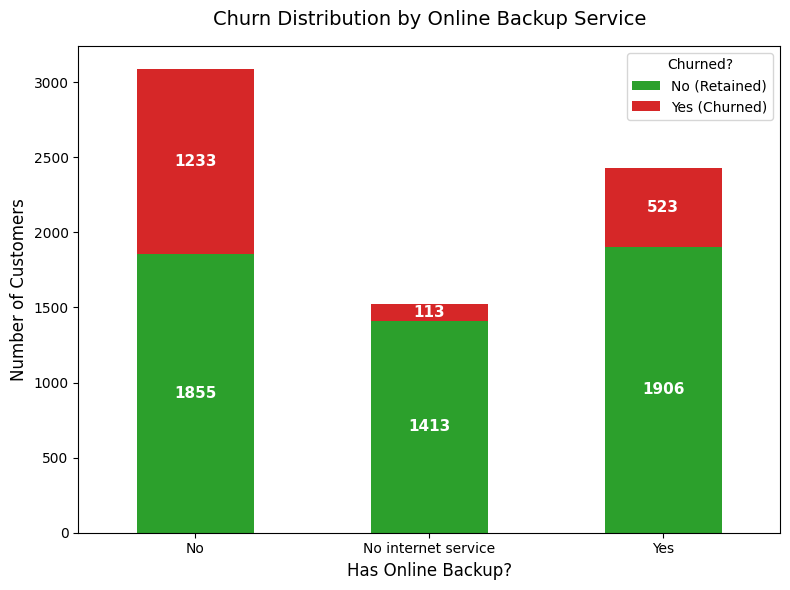

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a cross-tabulation of Online Backup and Churn Label
backup_churn = pd.crosstab(df['Online Backup'], df['Churn Label'])

# Plotting the stacked bar chart
ax = backup_churn.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#2ca02c', '#d62728'])

# Customizing titles and labels
plt.title('Churn Distribution by Online Backup Service', fontsize=14, pad=15)
plt.xlabel('Has Online Backup?', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Churned?', labels=['No (Retained)', 'Yes (Churned)'])

# Add exact value labels inside the stacked segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, 
                y + height/2, 
                f'{int(height)}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                weight='bold',
                fontsize=11)

plt.tight_layout()
plt.show()

In [15]:
# Map Online Backup based on your preference
df['Online Backup_encoded'] = df['Online Backup'].map({
    'No internet service': 0,
    'Yes': 1,
    'No': 2
})

# Verify the mapping works exactly as expected
df[['Online Backup', 'Online Backup_encoded']].drop_duplicates()

,Online Backup,Online Backup_encoded
0,Yes,1
1,No,2
7,No internet service,0


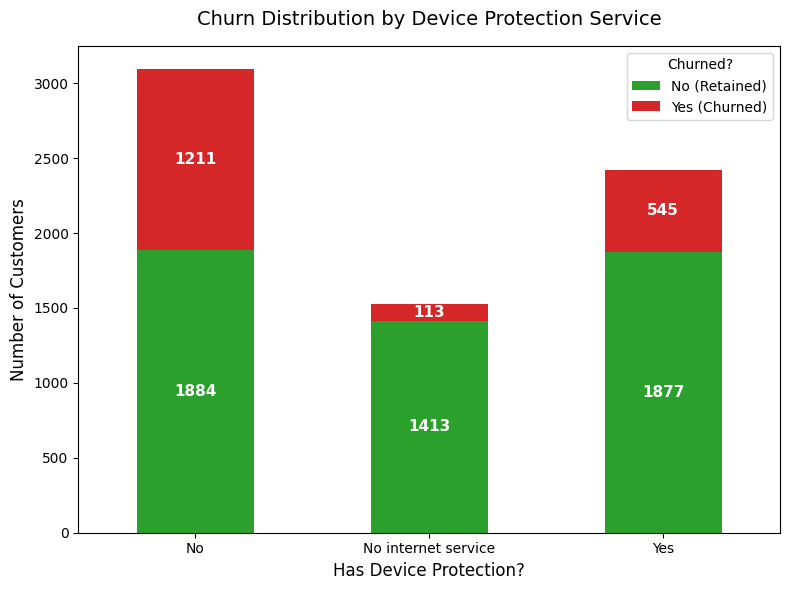

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a cross-tabulation of Device Protection and Churn Label
protection_churn = pd.crosstab(df['Device Protection'], df['Churn Label'])

# Plotting the stacked bar chart
ax = protection_churn.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#2ca02c', '#d62728'])

# Customizing titles and labels
plt.title('Churn Distribution by Device Protection Service', fontsize=14, pad=15)
plt.xlabel('Has Device Protection?', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Churned?', labels=['No (Retained)', 'Yes (Churned)'])

# Add exact value labels inside the stacked segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, 
                y + height/2, 
                f'{int(height)}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                weight='bold',
                fontsize=11)

plt.tight_layout()
plt.show()


In [17]:
# Map Device Protection based on your preference
df['Device Protection_encoded'] = df['Device Protection'].map({
    'No internet service': 0,
    'Yes': 1,
    'No': 2
})

# Verify the mapping works exactly as expected
df[['Device Protection', 'Device Protection_encoded']].drop_duplicates()

,Device Protection,Device Protection_encoded
0,No,2
2,Yes,1
7,No internet service,0


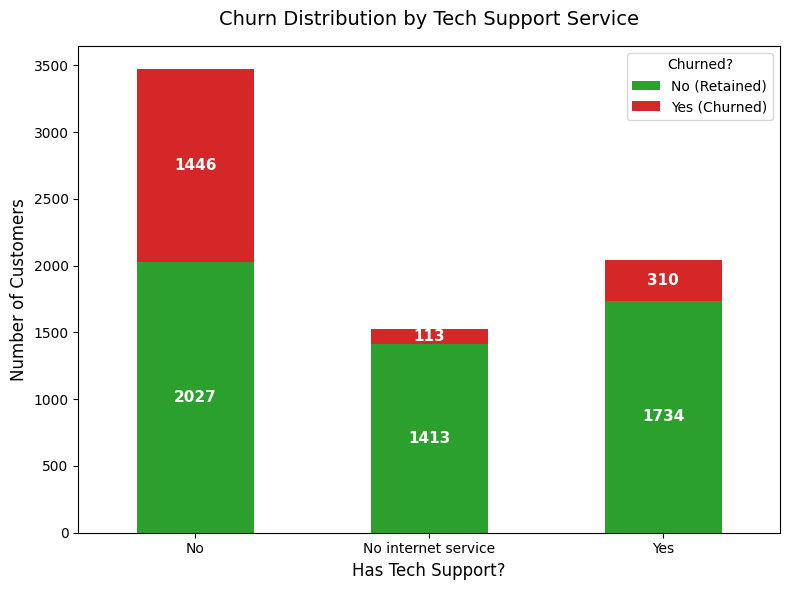

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a cross-tabulation of Tech Support and Churn Label
tech_churn = pd.crosstab(df['Tech Support'], df['Churn Label'])

# Plotting the stacked bar chart
ax = tech_churn.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#2ca02c', '#d62728'])

# Customizing titles and labels
plt.title('Churn Distribution by Tech Support Service', fontsize=14, pad=15)
plt.xlabel('Has Tech Support?', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Churned?', labels=['No (Retained)', 'Yes (Churned)'])

# Add exact value labels inside the stacked segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, 
                y + height/2, 
                f'{int(height)}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                weight='bold',
                fontsize=11)

plt.tight_layout()
plt.show()

In [19]:
# Map Tech Support based on your preference
df['Tech Support_encoded'] = df['Tech Support'].map({
    'No internet service': 0,
    'Yes': 1,
    'No': 2
})

# Verify the mapping works exactly as expected
df[['Tech Support', 'Tech Support_encoded']].drop_duplicates()

,Tech Support,Tech Support_encoded
0,No,2
3,Yes,1
7,No internet service,0


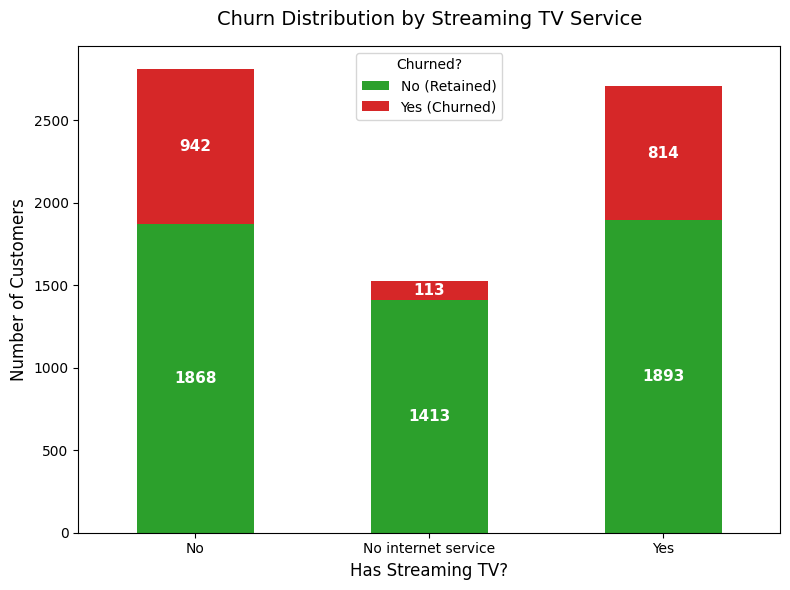

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a cross-tabulation of Streaming TV and Churn Label
streaming_tv_churn = pd.crosstab(df['Streaming TV'], df['Churn Label'])

# Plotting the stacked bar chart
ax = streaming_tv_churn.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#2ca02c', '#d62728'])

# Customizing titles and labels
plt.title('Churn Distribution by Streaming TV Service', fontsize=14, pad=15)
plt.xlabel('Has Streaming TV?', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Churned?', labels=['No (Retained)', 'Yes (Churned)'])

# Add exact value labels inside the stacked segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, 
                y + height/2, 
                f'{int(height)}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                weight='bold',
                fontsize=11)

plt.tight_layout()
plt.show()

In [21]:
# Map Streaming TV based on your preference
df['Streaming TV_encoded'] = df['Streaming TV'].map({
    'No internet service': 0,
    'Yes': 1,
    'No': 2
})

# Verify the mapping works exactly as expected
df[['Streaming TV', 'Streaming TV_encoded']].drop_duplicates()

,Streaming TV,Streaming TV_encoded
0,No,2
2,Yes,1
7,No internet service,0


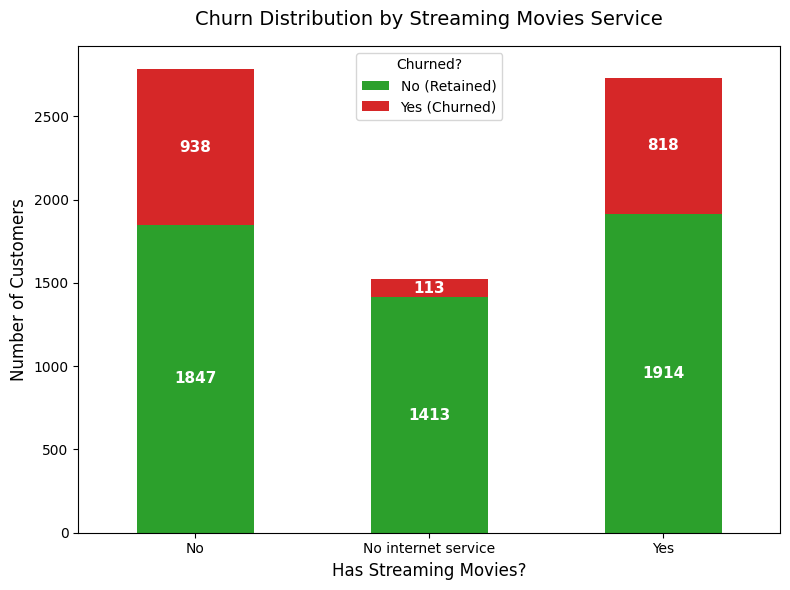

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a cross-tabulation of Streaming Movies and Churn Label
streaming_movies_churn = pd.crosstab(df['Streaming Movies'], df['Churn Label'])

# Plotting the stacked bar chart
ax = streaming_movies_churn.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#2ca02c', '#d62728'])

# Customizing titles and labels
plt.title('Churn Distribution by Streaming Movies Service', fontsize=14, pad=15)
plt.xlabel('Has Streaming Movies?', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Churned?', labels=['No (Retained)', 'Yes (Churned)'])

# Add exact value labels inside the stacked segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, 
                y + height/2, 
                f'{int(height)}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                weight='bold',
                fontsize=11)

plt.tight_layout()
plt.show()

In [23]:
# Map Streaming Movies based on your preference
df['Streaming Movies_encoded'] = df['Streaming Movies'].map({
    'No internet service': 0,
    'Yes': 1,
    'No': 2
})

# Verify the mapping works exactly as expected
df[['Streaming Movies', 'Streaming Movies_encoded']].drop_duplicates()

,Streaming Movies,Streaming Movies_encoded
0,No,2
2,Yes,1
7,No internet service,0


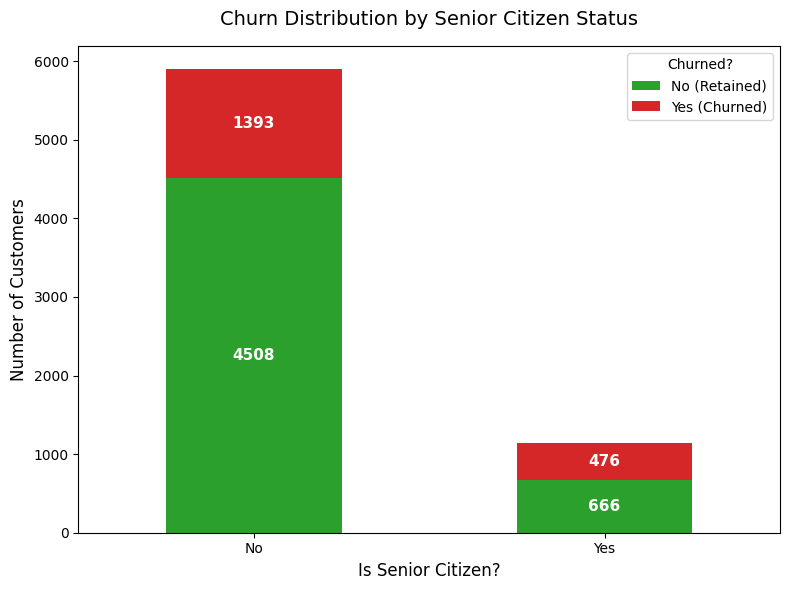

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a cross-tabulation of Senior Citizen and Churn Label
senior_churn = pd.crosstab(df['Senior Citizen'], df['Churn Label'])

# Plotting the stacked bar chart
ax = senior_churn.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#2ca02c', '#d62728'])

# Customizing titles and labels
plt.title('Churn Distribution by Senior Citizen Status', fontsize=14, pad=15)
plt.xlabel('Is Senior Citizen?', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Churned?', labels=['No (Retained)', 'Yes (Churned)'])

# Add exact value labels inside the stacked segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, 
                y + height/2, 
                f'{int(height)}', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white',
                weight='bold',
                fontsize=11)

plt.tight_layout()
plt.show()

In [25]:
# Map Senior Citizen based on your preference
df['Senior Citizen_encoded'] = df['Senior Citizen'].map({
    'Yes': 0,
    'No': 1
})

# Verify the mapping works exactly as expected
df[['Senior Citizen', 'Senior Citizen_encoded']].drop_duplicates()

,Senior Citizen,Senior Citizen_encoded
0,No,1
6,Yes,0


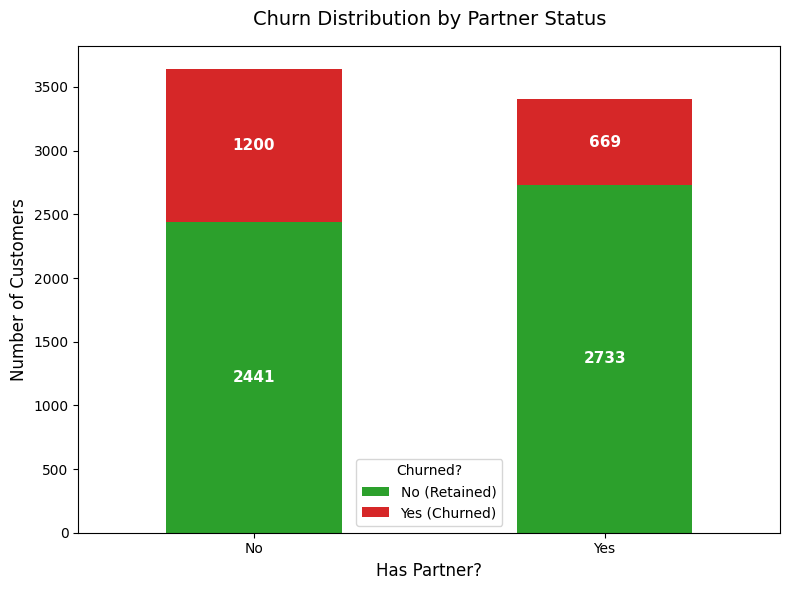

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a cross-tabulation of Partner and Churn Label
partner_churn = pd.crosstab(df['Partner'], df['Churn Label'])

# Plotting the stacked bar chart
ax = partner_churn.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#2ca02c', '#d62728'])

# Customizing titles and labels
plt.title('Churn Distribution by Partner Status', fontsize=14, pad=15)
plt.xlabel('Has Partner?', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Churned?', labels=['No (Retained)', 'Yes (Churned)'])

# Add exact value labels inside the stacked segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width / 2, y + height / 2, f'{int(height)}', 
                horizontalalignment='center', verticalalignment='center', 
                color='white', weight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [27]:
# Map Partner based on your preference (e.g., Yes: 0, No: 1)
df['Partner_encoded'] = df['Partner'].map({'No': 1, 'Yes': 0})

# Verify the mapping works exactly as expected
df[['Partner', 'Partner_encoded']].drop_duplicates()

,Partner,Partner_encoded
0,No,1
3,Yes,0


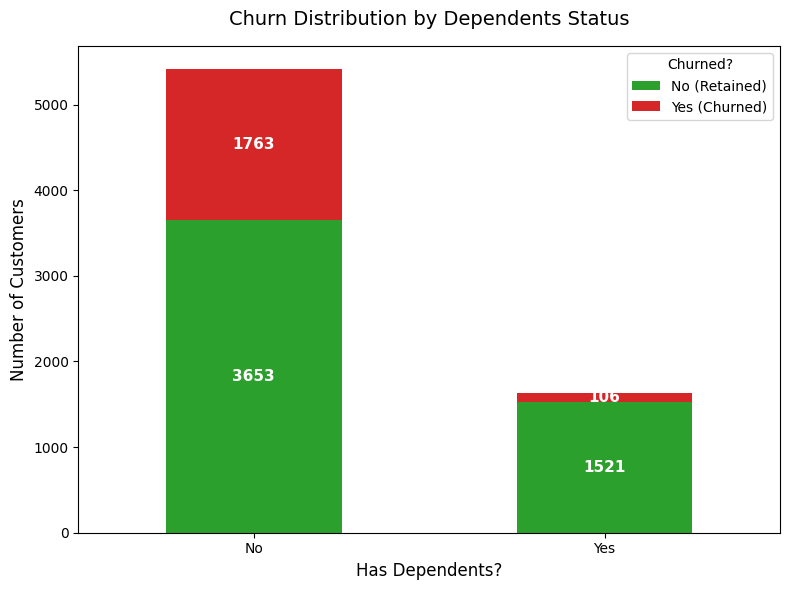

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a cross-tabulation of Dependents and Churn Label
dependents_churn = pd.crosstab(df['Dependents'], df['Churn Label'])

# Plotting the stacked bar chart
ax = dependents_churn.plot(kind='bar', stacked=True, figsize=(8, 6), color=['#2ca02c', '#d62728'])

# Customizing titles and labels
plt.title('Churn Distribution by Dependents Status', fontsize=14, pad=15)
plt.xlabel('Has Dependents?', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Churned?', labels=['No (Retained)', 'Yes (Churned)'])

# Add exact value labels inside the stacked segments
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width / 2, y + height / 2, f'{int(height)}', 
                horizontalalignment='center', verticalalignment='center', 
                color='white', weight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [29]:
# Map Dependents to maintain consistent tracking format
df['Dependents_encoded'] = df['Dependents'].map({'No': 1, 'Yes': 0})

# Verify the mapping works exactly as expected
df[['Dependents', 'Dependents_encoded']].drop_duplicates()

,Dependents,Dependents_encoded
0,No,1
1,Yes,0


In [30]:
df["Country"].unique()

array(['United States'], dtype=object)

In [31]:
df["State"].unique()

array(['California'], dtype=object)

In [32]:
df["City"].unique()

array(['Los Angeles', 'Beverly Hills', 'Huntington Park', ..., 'Standish',
       'Tulelake', 'Olympic Valley'], dtype=object)

In [33]:
# Map each city to its frequency ratio in the dataset
city_freq = df['City'].value_counts(normalize=True)
df['City_encoded_freq'] = df['City'].map(city_freq)

# Verify the frequency mapping
df[['City', 'City_encoded_freq']].drop_duplicates().head(10)

,City,City_encoded_freq
0,Los Angeles,0.043305
18,Beverly Hills,0.002130
19,Huntington Park,0.000710
20,Lynwood,0.000710
21,Marina Del Rey,0.000710
22,Inglewood,0.003550
24,Santa Monica,0.003550
25,Torrance,0.003550
26,Whittier,0.004260
28,La Habra,0.000710


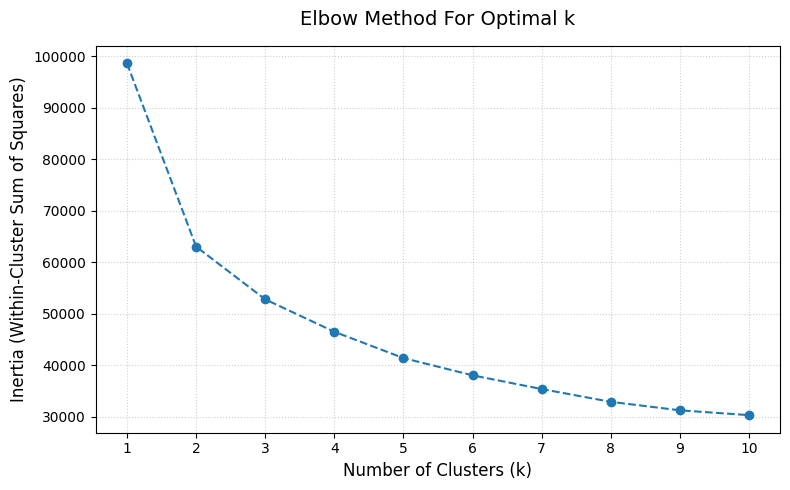

In [34]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Gather all the encoded features we've created
encoded_features = [
    'Contract_encoded', 'Phone Service_encoded', 'Multiple Lines_encoded', 
    'Internet Service_encoded', 'Online Security_encoded', 'Online Backup_encoded', 
    'Device Protection_encoded', 'Tech Support_encoded', 'Streaming TV_encoded', 
    'Streaming Movies_encoded', 'Senior Citizen_encoded', 'Partner_encoded', 
    'Dependents_encoded', 'City_encoded_freq'
]

X = df[encoded_features]

# 2. Scale the features so high-magnitude values don't dominate the distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Use the Elbow Method to find the optimal number of clusters
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 4. Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='#1f77b4')
plt.title('Elbow Method For Optimal k', fontsize=14, pad=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(K_range)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [35]:
# 1. Initialize and fit the final K-Means model with the optimal k=2
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 2. Quick check on how your customers are distributed across the 2 clusters
print("Customer distribution across clusters:")
print(df['Cluster'].value_counts().sort_index())
print("\n---")

# 3. Preview your dataframe with the new cluster assignments
df[['CustomerID', 'Contract', 'Internet Service', 'Cluster']].head(10)

Customer distribution across clusters:
Cluster
0    1526
1    5517
Name: count, dtype: int64

---


,CustomerID,Contract,Internet Service,Cluster
0,3668-QPYBK,Month-to-month,DSL,1
1,9237-HQITU,Month-to-month,Fiber optic,1
2,9305-CDSKC,Month-to-month,Fiber optic,1
3,7892-POOKP,Month-to-month,Fiber optic,1
4,0280-XJGEX,Month-to-month,Fiber optic,1
5,4190-MFLUW,Month-to-month,DSL,1
6,8779-QRDMV,Month-to-month,DSL,1
7,1066-JKSGK,Month-to-month,No,0
8,6467-CHFZW,Month-to-month,Fiber optic,1
9,8665-UTDHZ,Month-to-month,DSL,1


             🎯 CHURN PERFORMANCE REPORT               
Optimal Hyperparameters Found : {'C': 1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best Training Cross-Validation F1-Score : 0.6218
Overall Model ROC-AUC Discriminatory Power: 0.8479
Applied Operational Risk Threshold     : 0.2941
------------------------------------------------------------

 CLASSIFICATION METRICS PROFILE:
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.53      0.75      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

------------------------------------------------------------

 TEXT-BASED CONFUSION MATRIX:
  • True Negatives (Correctly predicted to Stay) : 789
  • False Positives (False Alarms / Safe Alerts) : 246
  • False Negatives (Missed Churn / Revenue Loss): 92
  • True Positives (

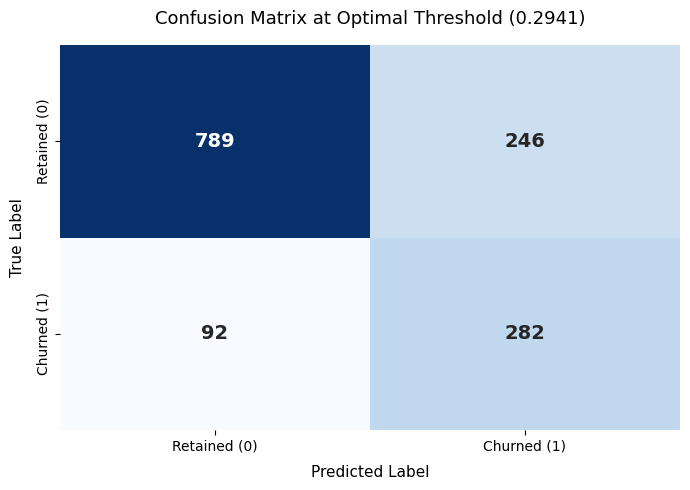

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# --- 1. DATA CLEANING & FEATURE PREPARATION ---
# Clean the empty space trap in Total Charges for new customers
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce').fillna(0)

# Define all categorical, engineered cluster, and high-precision continuous features
all_features = [
    'Contract_encoded', 'Phone Service_encoded', 'Multiple Lines_encoded', 
    'Internet Service_encoded', 'Online Security_encoded', 'Online Backup_encoded', 
    'Device Protection_encoded', 'Tech Support_encoded', 'Streaming TV_encoded', 
    'Streaming Movies_encoded', 'Senior Citizen_encoded', 'Partner_encoded', 
    'Dependents_encoded', 'City_encoded_freq', 'Cluster',
    'Tenure Months', 'Monthly Charges', 'Total Charges' 
]

X = df[all_features]
y = df['Churn Value']

# Stratified split to preserve the 26.5% churn balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale all mixed columns together
scaler_updated = StandardScaler()
X_train_scaled = scaler_updated.fit_transform(X_train)
X_test_scaled = scaler_updated.transform(X_test)


# --- 2. GRID SEARCH CV HYPERPARAMETER TUNING ---
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}

log_reg = LogisticRegression(random_state=42)
grid_search_updated = GridSearchCV(
    estimator=log_reg, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1
)
grid_search_updated.fit(X_train_scaled, y_train)

# Extract best model data
best_model_updated = grid_search_updated.best_estimator_
y_pred_proba_updated = best_model_updated.predict_proba(X_test_scaled)[:, 1]


# --- 3. CUSTOM OPERATIONAL THRESHOLD TRANSFORMATION ---
optimal_threshold = 0.2941
y_pred_optimal = (y_pred_proba_updated >= optimal_threshold).astype(int)


# --- 4. SINGLE GENERATED REPORT OUTPUT ---
print("="*60)
print("             🎯 CHURN PERFORMANCE REPORT               ")
print("="*60)
print(f"Optimal Hyperparameters Found : {grid_search_updated.best_params_}")
print(f"Best Training Cross-Validation F1-Score : {grid_search_updated.best_score_:.4f}")
print(f"Overall Model ROC-AUC Discriminatory Power: {roc_auc_score(y_test, y_pred_proba_updated):.4f}")
print(f"Applied Operational Risk Threshold     : {optimal_threshold}")
print("-"*60)

print("\n CLASSIFICATION METRICS PROFILE:")
print(classification_report(y_test, y_pred_optimal))
print("-"*60)

# Calculate matrix values
cm = confusion_matrix(y_test, y_pred_optimal)
print("\n TEXT-BASED CONFUSION MATRIX:")
print(f"  • True Negatives (Correctly predicted to Stay) : {cm[0][0]}")
print(f"  • False Positives (False Alarms / Safe Alerts) : {cm[0][1]}")
print(f"  • False Negatives (Missed Churn / Revenue Loss): {cm[1][0]}")
print(f"  • True Positives (Correctly caught Risks)       : {cm[1][1]}")
print("="*60)


# --- 5. VISUAL CONFUSION MATRIX PLOT ---
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Retained (0)', 'Churned (1)'],
            yticklabels=['Retained (0)', 'Churned (1)'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title(f'Confusion Matrix at Optimal Threshold ({optimal_threshold})', fontsize=13, pad=15)
plt.xlabel('Predicted Label', fontsize=11, labelpad=8)
plt.ylabel('True Label', fontsize=11, labelpad=8)
plt.tight_layout()
plt.show()

In [38]:
import joblib

# 1. Save the updated 18-feature scaler configuration
joblib.dump(scaler_updated, 'scaler.pkl')

# 2. Save the trained K-Means model to classify clusters dynamically in production
joblib.dump(kmeans_final, 'kmeans_cluster_model.pkl')

# 3. Save the final optimized Logistic Regression churn predictor
joblib.dump(best_model_updated, 'optimal_logistic_reg_model.pkl')

print("🎉 Successfully saved all 3 pipeline components: Scaler, K-Means, and Logistic Regression!")

🎉 Successfully saved all 3 pipeline components: Scaler, K-Means, and Logistic Regression!


In [ ]:
import joblib

# Load the saved components
loaded_scaler = joblib.load('scaler.pkl')
loaded_model = joblib.load('optimal_logistic_reg_model.pkl')

# Example: Predicting on new unseen raw data
# X_new_scaled = loaded_scaler.transform(X_new)
# y_new_proba = loaded_model.predict_proba(X_new_scaled)[:, 1]
# y_new_pred = (y_new_proba >= 0.2941).astype(int)